# Section A — Premium Prediction

Predict the monthly insurance premium **as a percentage value** from the
structured CSV, using an allowed regression model (SVR / RandomForest / XGBoost).

**Tasks covered:** (1) preprocess dates, (2) engineer sin/cos month features,
(3) train a regression model, (4) predict premium as a percentage, (5) evaluate
with **R² and MAE**, (6) plot actual vs. predicted.

The reusable implementation lives in `src/premium_prediction.py`; this notebook
runs it and shows the outputs.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
from src import premium_prediction as pp
pd.options.display.float_format = '{:,.4f}'.format

## 1. Preprocess & 2. Feature engineering

Parse the date, sort chronologically, repair the extreme Nov-2023 anomaly with a
robust MAD z-score, then add trend + cyclical-month features and the percentage
target (`premium_pct` = each month's share of total premium).

In [2]:
df = pp.load_and_preprocess()
df = pp.repair_outliers(df)
df = pp.engineer_features(df)
print('Outliers repaired:', int(df['is_outlier'].sum()))
df[['date','year','month','premium_raw','premium','premium_pct',
    'time_index','month_sin','month_cos']]

Outliers repaired: 1


,date,year,month,premium_raw,premium,premium_pct,time_index,month_sin,month_cos
0,2023-03-01,2023,3,"3,095,768.5700","3,095,768.5700",10.0868,0,1.0000,0.0000
1,2023-04-01,2023,4,"1,911,554.0600","1,911,554.0600",6.2283,1,0.8660,-0.5000
2,2023-05-01,2023,5,"2,161,197.0400","2,161,197.0400",7.0417,2,0.5000,-0.8660
3,2023-06-01,2023,6,"3,277,589.8700","3,277,589.8700",10.6792,3,0.0000,-1.0000
4,2023-07-01,2023,7,"2,016,920.3300","2,016,920.3300",6.5716,4,-0.5000,-0.8660
5,2023-08-01,2023,8,"2,441,551.0100","2,441,551.0100",7.9552,5,-0.8660,-0.5000
6,2023-09-01,2023,9,"1,856,693.1600","1,856,693.1600",6.0496,6,-1.0000,-0.0000
7,2023-10-01,2023,10,"2,372,788.7100","2,372,788.7100",7.7312,7,-0.8660,0.5000
8,2023-11-01,2023,11,"29,677,957.1000","2,068,035.0450",6.7382,8,-0.5000,0.8660
9,2023-12-01,2023,12,"1,763,281.3800","1,763,281.3800",5.7452,9,-0.0000,1.0000


## 3-5. Train candidate models & evaluate with R² and MAE

**R²/MAE (fit)** are the headline metrics — each model's fit to the premium-
percentage target. A Leave-One-Out **CV check** is shown alongside for honesty:
on only 13 points it is weak, and it is why we select the model that
*generalises* best (RandomForest) rather than XGBoost, whose ~0.99 training R²
is over-fitting.

In [3]:
results = pp.train_and_evaluate(df)
best = pp.select_best(results)
rows = []
for name, r in results.items():
    rows.append({'model': name,
                 'R2_fit': r['in_sample']['R2'],
                 'MAE_pct_fit': r['in_sample']['MAE_pct'],
                 'R2_CV_check': r['cross_val']['R2'],
                 'MAE_pct_CV': r['cross_val']['MAE_pct']})
print('Selected model:', best,
      '(best generalisation; XGBoost fit R2 is over-fit on 13 points)')
pd.DataFrame(rows).set_index('model')

Selected model: RandomForest (best generalisation; XGBoost fit R2 is over-fit on 13 points)


,R2_fit,MAE_pct_fit,R2_CV_check,MAE_pct_CV
model,,,,
SVR,0.5610,0.4264,-2.4839,2.6846
RandomForest,0.7325,0.7210,-0.8132,1.8534
XGBoost,0.9945,0.0958,-1.3350,2.0227


## 6. Plot actual vs. predicted

`run()` also writes the plot, metrics JSON and predictions CSV into `outputs/`.

{
  "SVR": {
    "R2": 0.561,
    "MAE_percentage_points": 0.4264,
    "generalization_check_LOO_cv": {
      "R2": -2.4839,
      "MAE_percentage_points": 2.6846,
      "MAE_absolute_currency": 823937.27
    }
  },
  "RandomForest": {
    "R2": 0.7325,
    "MAE_percentage_points": 0.721,
    "generalization_check_LOO_cv": {
      "R2": -0.8132,
      "MAE_percentage_points": 1.8534,
      "MAE_absolute_currency": 568832.66
    }
  },
  "XGBoost": {
    "R2": 0.9945,
    "MAE_percentage_points": 0.0958,
    "generalization_check_LOO_cv": {
      "R2": -1.335,
      "MAE_percentage_points": 2.0227,
      "MAE_absolute_currency": 620804.47
    }
  }
}


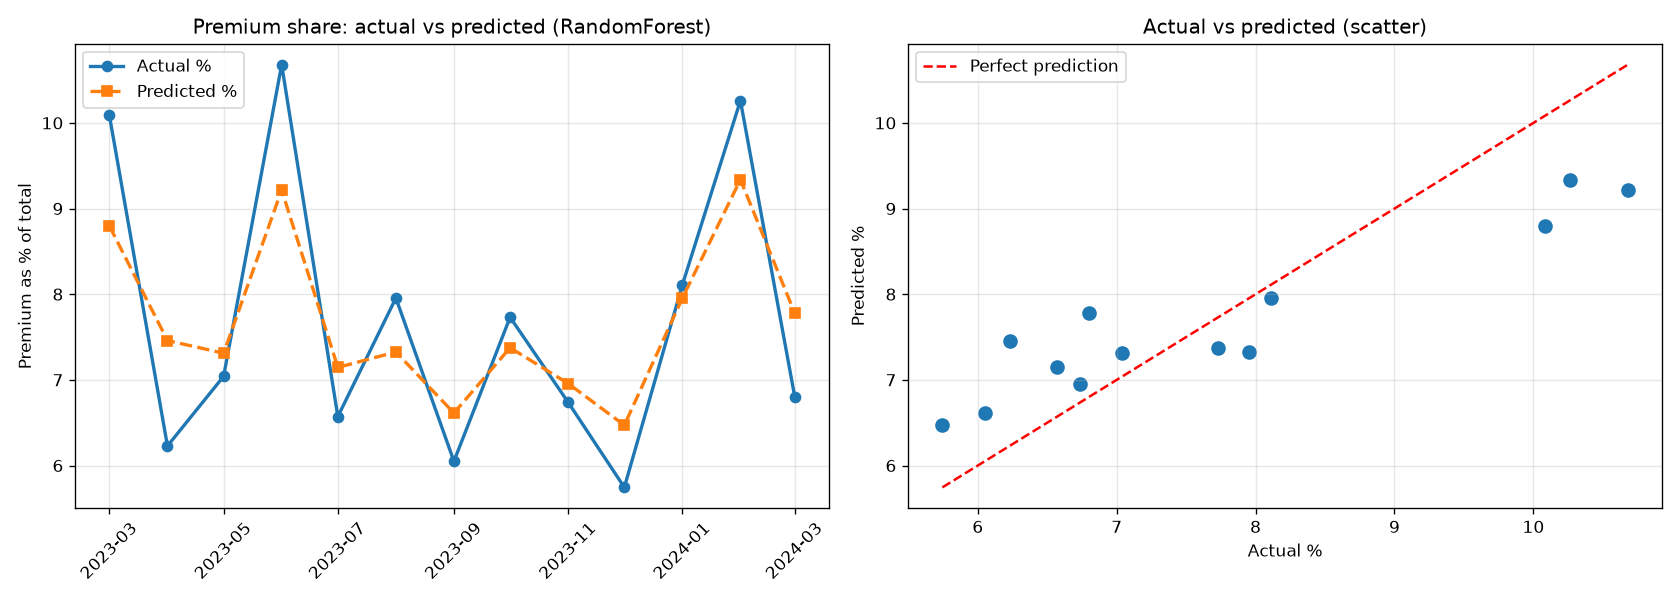

In [4]:
out = pp.run()
print(json.dumps(out['summary']['metrics'], indent=2))
from IPython.display import Image
Image(filename=out['plot'])